## 1. Imports and setup

In [1]:
import os
import re
import html
import json
import time
import joblib
import warnings
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import emoji
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "emoji"])
    import emoji

try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from google.colab import drive
from scipy.sparse import hstack, csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Mount Drive and set paths

In [2]:
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Sentimental Analysis"

TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
VAL_PATH = os.path.join(BASE_DIR, "val.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")

MODELS_DIR = os.path.join(BASE_DIR, "models_lightgbm")
RESULTS_DIR = os.path.join(BASE_DIR, "results_lightgbm")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("Train path:", TRAIN_PATH)
print("Validation path:", VAL_PATH)
print("Test path:", TEST_PATH)
print("LightGBM models dir:", MODELS_DIR)
print("LightGBM results dir:", RESULTS_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Sentimental Analysis
Train path: /content/drive/MyDrive/Sentimental Analysis/train.csv
Validation path: /content/drive/MyDrive/Sentimental Analysis/val.csv
Test path: /content/drive/MyDrive/Sentimental Analysis/test.csv
LightGBM models dir: /content/drive/MyDrive/Sentimental Analysis/models_lightgbm
LightGBM results dir: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm


## 3. Load data

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head())
display(train_df.columns)


Train shape: (34601, 2)
Val shape: (4943, 2)
Test shape: (9887, 2)


,text,status
0,Is anime bad ? Is anime bad ? I think it’s bad...,normal
1,horror wench me toooooo i feel like i ve been ...,normal
2,Context: My father-in-law is/was the ultimate ...,normal
3,Been trying the whole online dating thing have...,suicidal
4,á¨³ â™¡ Selling passive Caucasian Instagram fo...,normal


Index(['text', 'status'], dtype='object')

## 4. Detect text and label columns

In [4]:
possible_text_cols = ["text", "statement", "content", "post", "tweet", "clean_text"]
possible_label_cols = ["label", "status", "class", "target", "category"]

TEXT_COL = next((c for c in possible_text_cols if c in train_df.columns), None)
LABEL_COL = next((c for c in possible_label_cols if c in train_df.columns), None)

if TEXT_COL is None or LABEL_COL is None:
    raise ValueError(f"Không detect được text/label columns. Columns: {train_df.columns.tolist()}")

print("TEXT_COL:", TEXT_COL)
print("LABEL_COL:", LABEL_COL)
display(train_df[LABEL_COL].value_counts())


TEXT_COL: text
LABEL_COL: status


,count
status,
normal,12706
depression,10154
suicidal,7840
anxiety,3901


## 5. Clean text: emoji + special tags

In [5]:
def clean_text_for_ml(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)

    try:
        text = emoji.demojize(text, language="en")
    except TypeError:
        text = emoji.demojize(text)

    # :smiling_face: -> emoji_smiling_face
    text = re.sub(r":([a-zA-Z0-9_+\-]+):", lambda m: " emoji_" + m.group(1).lower() + " ", text)

    tag_map = {
        "<username>": " username_token ",
        "<user>": " username_token ",
        "<url>": " url_token ",
        "<link>": " url_token ",
        "<name>": " name_token ",
        "<number>": " number_token ",
        "<num>": " number_token "
    }
    for tag, replacement in tag_map.items():
        text = re.sub(re.escape(tag), replacement, text, flags=re.IGNORECASE)

    text = re.sub(r"https?://\S+|www\.\S+", " url_token ", text)
    text = re.sub(r"@\w+", " username_token ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\b\d+([.,]\d+)?\b", " number_token ", text)
    text = text.replace("’", "'").replace("`", "'").replace("´", "'")
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z0-9_\s\.\,\!\?']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, val_df, test_df]:
    df["clean_text"] = df[TEXT_COL].apply(clean_text_for_ml)

display(train_df[[TEXT_COL, "clean_text", LABEL_COL]].head())


,text,clean_text,status
0,Is anime bad ? Is anime bad ? I think it’s bad...,is anime bad ? is anime bad ? i think it's bad...,normal
1,horror wench me toooooo i feel like i ve been ...,horror wench me too i feel like i ve been on t...,normal
2,Context: My father-in-law is/was the ultimate ...,context my father in law is was the ultimate h...,normal
3,Been trying the whole online dating thing have...,been trying the whole online dating thing have...,suicidal
4,á¨³ â™¡ Selling passive Caucasian Instagram fo...,emoji_trade_mark selling passive caucasian ins...,normal


## 6. Handcrafted features

In [6]:
class TextStatsTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for text in X:
            text = "" if pd.isna(text) else str(text)
            words = text.split()
            char_len = len(text)
            word_count = len(words)
            unique_word_count = len(set(words))
            avg_word_len = np.mean([len(w) for w in words]) if words else 0.0
            lexical_diversity = unique_word_count / word_count if word_count > 0 else 0.0

            depression_keywords = ["depress", "sad", "hopeless", "worthless", "empty", "cry", "lonely", "tired", "pain", "numb"]
            suicidal_keywords = ["suicide", "suicidal", "kill", "die", "death", "end", "overdose", "jump", "cut", "hurt myself"]
            anxiety_keywords = ["anxiety", "anxious", "panic", "worry", "worried", "fear", "scared", "heart", "breath", "chest"]

            features.append([
                char_len, word_count, unique_word_count, avg_word_len, lexical_diversity,
                text.count("!"), text.count("?"), text.count(","), text.count("."), text.count("'"),
                len(re.findall(r"\bemoji_[a-z0-9_]+\b", text)),
                text.count("username_token"), text.count("url_token"), text.count("number_token"),
                sum(text.count(k) for k in depression_keywords),
                sum(text.count(k) for k in suicidal_keywords),
                sum(text.count(k) for k in anxiety_keywords),
            ])
        return np.array(features, dtype=float)

handcrafted_feature_names = [
    "char_len", "word_count", "unique_word_count", "avg_word_len", "lexical_diversity",
    "exclamation_count", "question_count", "comma_count", "period_count", "apostrophe_count",
    "emoji_token_count", "username_count", "url_count", "number_count",
    "depression_keyword_count", "suicidal_keyword_count", "anxiety_keyword_count"
]
print("Handcrafted features:", len(handcrafted_feature_names))


Handcrafted features: 17


## 7. Encode labels

In [7]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[LABEL_COL])
y_val = label_encoder.transform(val_df[LABEL_COL])
y_test = label_encoder.transform(test_df[LABEL_COL])
class_names = label_encoder.classes_

print("Classes:", class_names)


Classes: ['anxiety' 'depression' 'normal' 'suicidal']


## 8. TF-IDF + handcrafted feature matrix

In [8]:
# Colab-friendly setting for LightGBM.
WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 10000

word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=WORD_MAX_FEATURES,
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode"
)

char_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 4),
    max_features=CHAR_MAX_FEATURES,
    min_df=3,
    sublinear_tf=True
)

stats_transformer = TextStatsTransformer()
stats_scaler = MinMaxScaler()

print("Fitting word TF-IDF...")
X_train_word = word_tfidf.fit_transform(train_df["clean_text"])
X_val_word = word_tfidf.transform(val_df["clean_text"])
X_test_word = word_tfidf.transform(test_df["clean_text"])

print("Fitting char TF-IDF...")
X_train_char = char_tfidf.fit_transform(train_df["clean_text"])
X_val_char = char_tfidf.transform(val_df["clean_text"])
X_test_char = char_tfidf.transform(test_df["clean_text"])

print("Extracting handcrafted features...")
X_train_stats = stats_transformer.fit_transform(train_df["clean_text"])
X_val_stats = stats_transformer.transform(val_df["clean_text"])
X_test_stats = stats_transformer.transform(test_df["clean_text"])

X_train_stats = stats_scaler.fit_transform(X_train_stats)
X_val_stats = stats_scaler.transform(X_val_stats)
X_test_stats = stats_scaler.transform(X_test_stats)

X_train = hstack([X_train_word, X_train_char, csr_matrix(X_train_stats)], format="csr")
X_val = hstack([X_val_word, X_val_char, csr_matrix(X_val_stats)], format="csr")
X_test = hstack([X_test_word, X_test_char, csr_matrix(X_test_stats)], format="csr")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


Fitting word TF-IDF...
Fitting char TF-IDF...
Extracting handcrafted features...
X_train: (34601, 40017)
X_val: (4943, 40017)
X_test: (9887, 40017)


## 9. SelectKBest chi2 feature selection

In [9]:
K_BEST = min(30000, X_train.shape[1])
selector = SelectKBest(score_func=chi2, k=K_BEST)

print(f"Selecting top {K_BEST} features...")
start_select = time.perf_counter()
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)
select_time = time.perf_counter() - start_select

print("Feature selection time:", round(select_time, 4), "seconds")
print("X_train_selected:", X_train_selected.shape)
print("X_val_selected:", X_val_selected.shape)
print("X_test_selected:", X_test_selected.shape)


Selecting top 30000 features...
Feature selection time: 1.5511 seconds
X_train_selected: (34601, 30000)
X_val_selected: (4943, 30000)
X_test_selected: (9887, 30000)


## 10. Evaluation function

In [10]:
def evaluate_model(model, X, y_true, dataset_name="Validation", save_report_path=None):
    start_infer = time.perf_counter()
    y_pred = model.predict(X)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / X.shape[0]

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {dataset_name} Result =====")
    print(f"Accuracy              : {acc:.5f}")
    print(f"Macro F1              : {macro_f1:.5f}")
    print(f"Weighted F1           : {weighted_f1:.5f}")
    print(f"Inference time total  : {infer_time_total:.4f} seconds")
    print(f"Avg inference time    : {infer_time_avg:.8f} seconds/sample")
    print()

    report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
    print(report_text)

    if save_report_path is not None:
        pd.DataFrame(report_dict).transpose().to_csv(save_report_path)
        print("Saved classification report to:", save_report_path)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "infer_time_total_sec": infer_time_total,
        "infer_time_avg_sec_per_sample": infer_time_avg,
        "classification_report": report_dict,
        "y_pred": y_pred
    }


## 11. Tune LightGBM by validation macro-F1

In [11]:
param_grid = [
    {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 63, "max_depth": -1, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 800, "learning_rate": 0.03, "num_leaves": 31, "max_depth": -1, "min_child_samples": 30, "subsample": 0.8, "colsample_bytree": 0.8},
]

lgbm_results = []

for i, params in enumerate(param_grid, start=1):
    print("=" * 100)
    print(f"Training LightGBM config {i}/{len(param_grid)}")
    print(params)

    model = LGBMClassifier(
        objective="multiclass",
        num_class=len(class_names),
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
        **params
    )

    start_train = time.perf_counter()
    model.fit(
        X_train_selected,
        y_train,
        eval_set=[(X_val_selected, y_val)],
        eval_metric="multi_logloss",
        callbacks=[early_stopping(stopping_rounds=50, verbose=False), log_evaluation(period=0)]
    )
    train_time = time.perf_counter() - start_train

    start_infer = time.perf_counter()
    val_pred = model.predict(X_val_selected)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / X_val_selected.shape[0]

    val_acc = accuracy_score(y_val, val_pred)
    val_macro_f1 = f1_score(y_val, val_pred, average="macro")
    val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")

    print(f"Best iteration     : {model.best_iteration_}")
    print(f"Val Accuracy       : {val_acc:.5f}")
    print(f"Val Macro F1       : {val_macro_f1:.5f}")
    print(f"Val Weighted F1    : {val_weighted_f1:.5f}")
    print(f"Training time      : {train_time:.4f} seconds")
    print(f"Avg inference time : {infer_time_avg:.8f} seconds/sample")

    lgbm_results.append({
        **params,
        "config_id": i,
        "model": model,
        "best_iteration": int(model.best_iteration_) if model.best_iteration_ is not None else None,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "train_time_sec": train_time,
        "val_infer_time_total_sec": infer_time_total,
        "val_infer_time_avg_sec_per_sample": infer_time_avg
    })

lgbm_results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in lgbm_results]).sort_values("val_macro_f1", ascending=False)
display(lgbm_results_df)


Training LightGBM config 1/2
{'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration     : 231
Val Accuracy       : 0.81813
Val Macro F1       : 0.80744
Val Weighted F1    : 0.81698
Training time      : 3475.2431 seconds
Avg inference time : 0.00016723 seconds/sample
Training LightGBM config 2/2
{'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best iteration     : 665
Val Accuracy       : 0.81954
Val Macro F1       : 0.81000
Val Weighted F1    : 0.81853
Training time      : 4454.8067 seconds
Avg inference time : 0.00042154 seconds/sample


,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,config_id,best_iteration,val_accuracy,val_macro_f1,val_weighted_f1,train_time_sec,val_infer_time_total_sec,val_infer_time_avg_sec_per_sample
1,800,0.03,31,-1,30,0.8,0.8,2,665,0.819543,0.809995,0.818529,4454.806662,2.083676,0.000422
0,500,0.05,63,-1,20,0.8,0.8,1,231,0.818127,0.807436,0.816985,3475.243099,0.826620,0.000167


## 12. Select best model

In [12]:
best_result = max(lgbm_results, key=lambda x: x["val_macro_f1"])
best_model = best_result["model"]

print("Best LightGBM configuration:")
for key, value in best_result.items():
    if key != "model":
        print(f"{key}: {value}")


Best LightGBM configuration:
n_estimators: 800
learning_rate: 0.03
num_leaves: 31
max_depth: -1
min_child_samples: 30
subsample: 0.8
colsample_bytree: 0.8
config_id: 2
best_iteration: 665
val_accuracy: 0.8195427877807
val_macro_f1: 0.8099953872112703
val_weighted_f1: 0.81852921129779
train_time_sec: 4454.806661879999
val_infer_time_total_sec: 2.0836762039998575
val_infer_time_avg_sec_per_sample: 0.0004215408059882374


## 13. Validation evaluation

In [13]:
val_metrics = evaluate_model(
    best_model,
    X_val_selected,
    y_val,
    dataset_name="Validation",
    save_report_path=os.path.join(RESULTS_DIR, "lightgbm_validation_classification_report.csv")
)


===== Validation Result =====
Accuracy              : 0.81954
Macro F1              : 0.81000
Weighted F1           : 0.81853
Inference time total  : 1.5645 seconds
Avg inference time    : 0.00031650 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8416    0.8492    0.8454       557
  depression     0.7721    0.7167    0.7434      1451
      normal     0.9172    0.9455    0.9311      1815
    suicidal     0.7068    0.7339    0.7201      1120

    accuracy                         0.8195      4943
   macro avg     0.8094    0.8113    0.8100      4943
weighted avg     0.8184    0.8195    0.8185      4943

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm/lightgbm_validation_classification_report.csv


## 14. Test evaluation before final retraining

In [14]:
test_metrics = evaluate_model(
    best_model,
    X_test_selected,
    y_test,
    dataset_name="Test before final retrain",
    save_report_path=os.path.join(RESULTS_DIR, "lightgbm_test_classification_report_before_final.csv")
)


===== Test before final retrain Result =====
Accuracy              : 0.81825
Macro F1              : 0.80947
Weighted F1           : 0.81789
Inference time total  : 3.4689 seconds
Avg inference time    : 0.00035085 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8407    0.8565    0.8485      1115
  depression     0.7618    0.7209    0.7408      2902
      normal     0.9288    0.9386    0.9337      3630
    suicidal     0.7000    0.7304    0.7149      2240

    accuracy                         0.8182      9887
   macro avg     0.8078    0.8116    0.8095      9887
weighted avg     0.8180    0.8182    0.8179      9887

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm/lightgbm_test_classification_report_before_final.csv


## 15. Test confusion matrix before final retraining

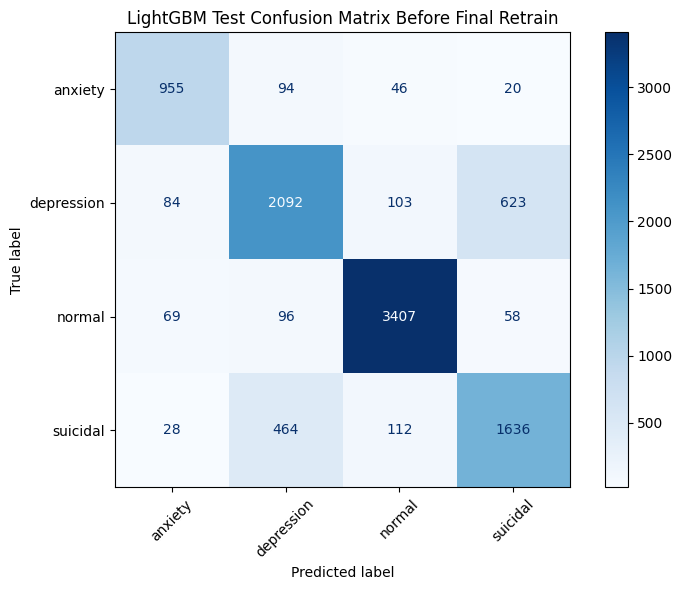

Saved test confusion matrix to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm/lightgbm_test_confusion_matrix_before_final.png


In [15]:
test_cm = confusion_matrix(y_test, test_metrics["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("LightGBM Test Confusion Matrix Before Final Retrain")
plt.tight_layout()
test_cm_path = os.path.join(RESULTS_DIR, "lightgbm_test_confusion_matrix_before_final.png")
plt.savefig(test_cm_path, dpi=200)
plt.show()
print("Saved test confusion matrix to:", test_cm_path)


## 16. Refit features on train + validation

In [16]:
train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
y_train_val = label_encoder.transform(train_val_df[LABEL_COL])

word_tfidf_final = TfidfVectorizer(
    analyzer="word", ngram_range=(1, 2), max_features=WORD_MAX_FEATURES,
    min_df=3, max_df=0.95, sublinear_tf=True, strip_accents="unicode"
)
char_tfidf_final = TfidfVectorizer(
    analyzer="char", ngram_range=(3, 4), max_features=CHAR_MAX_FEATURES,
    min_df=3, sublinear_tf=True
)
stats_transformer_final = TextStatsTransformer()
stats_scaler_final = MinMaxScaler()

print("Fitting final word TF-IDF...")
X_train_val_word = word_tfidf_final.fit_transform(train_val_df["clean_text"])
X_test_word_final = word_tfidf_final.transform(test_df["clean_text"])

print("Fitting final char TF-IDF...")
X_train_val_char = char_tfidf_final.fit_transform(train_val_df["clean_text"])
X_test_char_final = char_tfidf_final.transform(test_df["clean_text"])

print("Extracting final handcrafted features...")
X_train_val_stats = stats_transformer_final.fit_transform(train_val_df["clean_text"])
X_test_stats_final = stats_transformer_final.transform(test_df["clean_text"])
X_train_val_stats = stats_scaler_final.fit_transform(X_train_val_stats)
X_test_stats_final = stats_scaler_final.transform(X_test_stats_final)

X_train_val_final = hstack([X_train_val_word, X_train_val_char, csr_matrix(X_train_val_stats)], format="csr")
X_test_final = hstack([X_test_word_final, X_test_char_final, csr_matrix(X_test_stats_final)], format="csr")

print("X_train_val_final:", X_train_val_final.shape)
print("X_test_final:", X_test_final.shape)


Fitting final word TF-IDF...
Fitting final char TF-IDF...
Extracting final handcrafted features...
X_train_val_final: (39544, 40017)
X_test_final: (9887, 40017)


## 17. Final feature selection

In [17]:
K_BEST_FINAL = min(K_BEST, X_train_val_final.shape[1])
selector_final = SelectKBest(score_func=chi2, k=K_BEST_FINAL)

print(f"Selecting final top {K_BEST_FINAL} features...")
start_final_select = time.perf_counter()
X_train_val_selected = selector_final.fit_transform(X_train_val_final, y_train_val)
X_test_final_selected = selector_final.transform(X_test_final)
final_select_time = time.perf_counter() - start_final_select

print("Final feature selection time:", round(final_select_time, 4), "seconds")
print("X_train_val_selected:", X_train_val_selected.shape)
print("X_test_final_selected:", X_test_final_selected.shape)


Selecting final top 30000 features...
Final feature selection time: 1.1904 seconds
X_train_val_selected: (39544, 30000)
X_test_final_selected: (9887, 30000)


## 18. Train final LightGBM on train + validation

In [18]:
final_params = {
    "n_estimators": int(best_result["n_estimators"]),
    "learning_rate": float(best_result["learning_rate"]),
    "num_leaves": int(best_result["num_leaves"]),
    "max_depth": int(best_result["max_depth"]),
    "min_child_samples": int(best_result["min_child_samples"]),
    "subsample": float(best_result["subsample"]),
    "colsample_bytree": float(best_result["colsample_bytree"]),
}

final_model = LGBMClassifier(
    objective="multiclass",
    num_class=len(class_names),
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
    **final_params
)

print("Training final LightGBM on train + validation...")
start_final_train = time.perf_counter()
final_model.fit(X_train_val_selected, y_train_val)
final_train_time = time.perf_counter() - start_final_train

print("Done.")
print(f"Final training time: {final_train_time:.4f} seconds")


Training final LightGBM on train + validation...
Done.
Final training time: 5735.0841 seconds


## 19. Final test evaluation

In [19]:
final_test_metrics = evaluate_model(
    final_model,
    X_test_final_selected,
    y_test,
    dataset_name="Final Test",
    save_report_path=os.path.join(RESULTS_DIR, "lightgbm_final_test_classification_report.csv")
)


===== Final Test Result =====
Accuracy              : 0.81895
Macro F1              : 0.81055
Weighted F1           : 0.81861
Inference time total  : 7.2478 seconds
Avg inference time    : 0.00073307 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8408    0.8619    0.8512      1115
  depression     0.7601    0.7185    0.7387      2902
      normal     0.9311    0.9388    0.9350      3630
    suicidal     0.7018    0.7335    0.7173      2240

    accuracy                         0.8190      9887
   macro avg     0.8085    0.8132    0.8105      9887
weighted avg     0.8188    0.8190    0.8186      9887

Saved classification report to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm/lightgbm_final_test_classification_report.csv


## 20. Final test confusion matrix

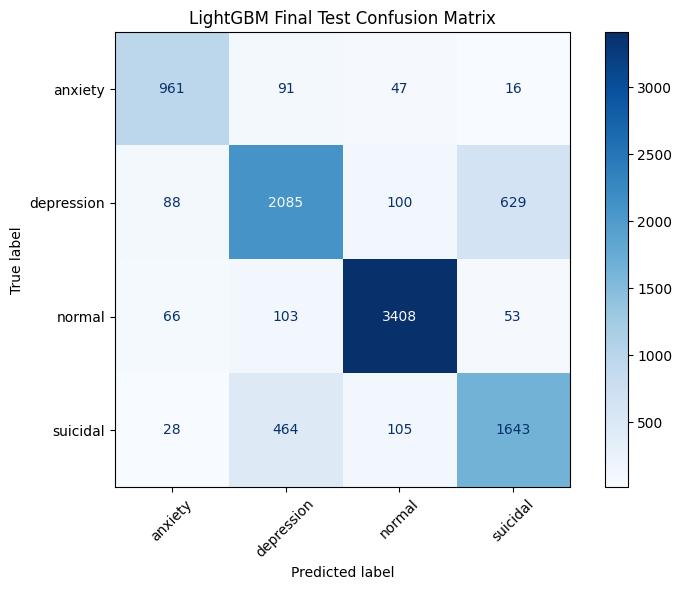

Saved final test confusion matrix to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm/lightgbm_final_test_confusion_matrix.png


In [20]:
final_test_cm = confusion_matrix(y_test, final_test_metrics["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=final_test_cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("LightGBM Final Test Confusion Matrix")
plt.tight_layout()
final_test_cm_path = os.path.join(RESULTS_DIR, "lightgbm_final_test_confusion_matrix.png")
plt.savefig(final_test_cm_path, dpi=200)
plt.show()
print("Saved final test confusion matrix to:", final_test_cm_path)


## 21. Save model and results

In [21]:
joblib.dump(word_tfidf_final, os.path.join(MODELS_DIR, "lightgbm_word_tfidf.joblib"))
joblib.dump(char_tfidf_final, os.path.join(MODELS_DIR, "lightgbm_char_tfidf.joblib"))
joblib.dump(stats_transformer_final, os.path.join(MODELS_DIR, "lightgbm_text_stats_transformer.joblib"))
joblib.dump(stats_scaler_final, os.path.join(MODELS_DIR, "lightgbm_stats_scaler.joblib"))
joblib.dump(selector_final, os.path.join(MODELS_DIR, "lightgbm_feature_selector.joblib"))
joblib.dump(final_model, os.path.join(MODELS_DIR, "final_lightgbm_model.joblib"))
joblib.dump(label_encoder, os.path.join(MODELS_DIR, "lightgbm_label_encoder.joblib"))

best_config = {
    "model": "TF-IDF word + char + handcrafted features + SelectKBest chi2 + LightGBM",
    "optimization_metric": "validation_macro_f1",
    "word_tfidf_max_features": WORD_MAX_FEATURES,
    "word_ngram_range": "(1, 2)",
    "char_tfidf_max_features": CHAR_MAX_FEATURES,
    "char_ngram_range": "(3, 4)",
    "selected_features_k": K_BEST_FINAL,
    "best_params": final_params,
    "best_validation_config_id": int(best_result["config_id"]),
    "best_iteration": int(best_result["best_iteration"]) if best_result["best_iteration"] is not None else None,
    "validation_accuracy": float(best_result["val_accuracy"]),
    "validation_macro_f1": float(best_result["val_macro_f1"]),
    "validation_weighted_f1": float(best_result["val_weighted_f1"]),
    "best_model_train_time_sec": float(best_result["train_time_sec"]),
    "test_accuracy_before_final_retrain": float(test_metrics["accuracy"]),
    "test_macro_f1_before_final_retrain": float(test_metrics["macro_f1"]),
    "test_weighted_f1_before_final_retrain": float(test_metrics["weighted_f1"]),
    "feature_selection_time_sec": float(select_time),
    "final_feature_selection_time_sec": float(final_select_time),
    "final_train_time_sec": float(final_train_time),
    "final_test_accuracy": float(final_test_metrics["accuracy"]),
    "final_test_macro_f1": float(final_test_metrics["macro_f1"]),
    "final_test_weighted_f1": float(final_test_metrics["weighted_f1"]),
    "final_test_infer_time_total_sec": float(final_test_metrics["infer_time_total_sec"]),
    "final_test_infer_time_avg_sec_per_sample": float(final_test_metrics["infer_time_avg_sec_per_sample"])
}

with open(os.path.join(RESULTS_DIR, "lightgbm_best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

lgbm_results_df.to_csv(os.path.join(RESULTS_DIR, "lightgbm_tuning_results.csv"), index=False)

print("Saved LightGBM model files to:", MODELS_DIR)
print("Saved LightGBM result files to:", RESULTS_DIR)


Saved LightGBM model files to: /content/drive/MyDrive/Sentimental Analysis/models_lightgbm
Saved LightGBM result files to: /content/drive/MyDrive/Sentimental Analysis/results_lightgbm


## 22. Load saved model and prediction helper

In [22]:
loaded_word_tfidf = joblib.load(os.path.join(MODELS_DIR, "lightgbm_word_tfidf.joblib"))
loaded_char_tfidf = joblib.load(os.path.join(MODELS_DIR, "lightgbm_char_tfidf.joblib"))
loaded_stats_transformer = joblib.load(os.path.join(MODELS_DIR, "lightgbm_text_stats_transformer.joblib"))
loaded_stats_scaler = joblib.load(os.path.join(MODELS_DIR, "lightgbm_stats_scaler.joblib"))
loaded_selector = joblib.load(os.path.join(MODELS_DIR, "lightgbm_feature_selector.joblib"))
loaded_model = joblib.load(os.path.join(MODELS_DIR, "final_lightgbm_model.joblib"))
loaded_label_encoder = joblib.load(os.path.join(MODELS_DIR, "lightgbm_label_encoder.joblib"))

print("Loaded LightGBM model successfully.")


def build_features_for_texts(texts):
    cleaned_texts = [clean_text_for_ml(t) for t in texts]
    X_word = loaded_word_tfidf.transform(cleaned_texts)
    X_char = loaded_char_tfidf.transform(cleaned_texts)
    X_stats = loaded_stats_transformer.transform(cleaned_texts)
    X_stats = loaded_stats_scaler.transform(X_stats)
    X_all = hstack([X_word, X_char, csr_matrix(X_stats)], format="csr")
    X_selected = loaded_selector.transform(X_all)
    return cleaned_texts, X_selected


def predict_mental_health_lightgbm(text):
    cleaned_texts, X_selected = build_features_for_texts([text])
    pred_id = loaded_model.predict(X_selected)[0]
    pred_label = loaded_label_encoder.inverse_transform([pred_id])[0]
    probs = loaded_model.predict_proba(X_selected)[0]
    prob_dict = {label: float(prob) for label, prob in zip(loaded_label_encoder.classes_, probs)}
    return {
        "input_text": text,
        "cleaned_text": cleaned_texts[0],
        "prediction": pred_label,
        "probabilities": prob_dict
    }

examples = [
    "I feel so tired and hopeless every day 😢. I don't know what to do anymore.",
    "@john My chest feels tight and I keep worrying that something bad will happen.",
    "I had lunch with my friend today and watched a movie. Visit https://example.com",
    "<username> I want to end my life. I can't take this pain anymore. <number>"
]

for text in examples:
    result = predict_mental_health_lightgbm(text)
    print("=" * 100)
    print("Input:", result["input_text"])
    print("Cleaned:", result["cleaned_text"])
    print("Prediction:", result["prediction"])
    print("Probabilities:", result["probabilities"])


Loaded LightGBM model successfully.
Input: I feel so tired and hopeless every day 😢. I don't know what to do anymore.
Cleaned: i feel so tired and hopeless every day emoji_crying_face . i don't know what to do anymore.
Prediction: depression
Probabilities: {'anxiety': 0.010073099700447011, 'depression': 0.5469565940923974, 'normal': 0.17049411982380258, 'suicidal': 0.27247618638335297}
Input: @john My chest feels tight and I keep worrying that something bad will happen.
Cleaned: username_token my chest feels tight and i keep worrying that something bad will happen.
Prediction: anxiety
Probabilities: {'anxiety': 0.6523718348092843, 'depression': 0.031576427356632235, 'normal': 0.07723161746621425, 'suicidal': 0.23882012036786937}
Input: I had lunch with my friend today and watched a movie. Visit https://example.com
Cleaned: i had lunch with my friend today and watched a movie. visit url_token
Prediction: normal
Probabilities: {'anxiety': 0.009782629006131844, 'depression': 0.00237934514